    id_evenement        date  annee     type_evenement       gravite  \
0              1  2010-02-11   2010          collision         grave   
1              2  2010-05-03   2010  incident_materiel  significatif   
2              3  2010-09-18   2010                 PN         grave   
3              4  2011-01-24   2011       deraillement  significatif   
4              5  2011-04-09   2011  acte_malveillance  significatif   
5              6  2011-07-21   2011  incident_materiel        mineur   
6              7  2011-11-30   2011           incendie         grave   
7              8  2012-02-15   2012                 PN  significatif   
8              9  2012-03-28   2012          collision         grave   
9             10  2012-06-10   2012  incident_materiel        mineur   
10            11  2012-10-19   2012       deraillement         grave   
11            12  2013-01-05   2013  acte_malveillance  significatif   
12            13  2013-03-22   2013                 PN         g

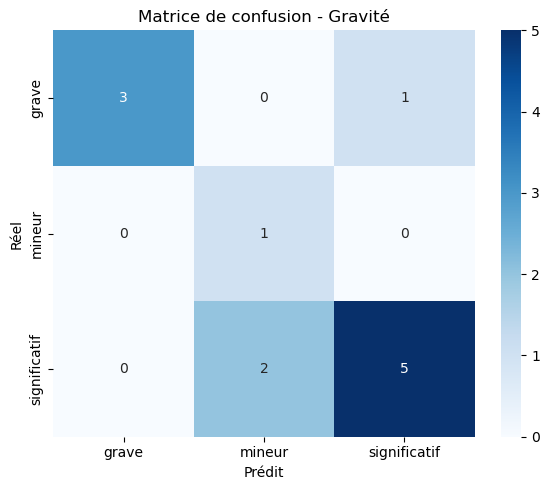


Top 20 features les plus importantes :
source_BEATT_rapport                    0.133944
type_evenement_incident_materiel        0.128388
source_SNCF_rapport                     0.106215
exploitant_SNCF Réseau                  0.101078
exploitant_SNCF Voyageurs               0.066718
annee                                   0.060223
cause_presumee_defaillance_materiel     0.060188
departement                             0.050439
cause_presumee_defaillance_freinage     0.036576
source_EPSF_synthese                    0.032975
cause_presumee_erreur_humaine           0.031436
contexte_essais                         0.028540
type_evenement_acte_malveillance        0.022080
contexte_maintenance                    0.021671
type_evenement_collision                0.018777
contexte_PN                             0.017965
type_evenement_PN                       0.016264
contexte_circulation_commerciale        0.014106
exploitant_RATP                         0.009338
cause_presumee_defaut_infrast

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Chargement du CSV
df = pd.read_csv(r"C:\Users\Utilisateur\Documents\2026-03-17_projet_final_certification_devIA\data\evenements.csv")
print(df)

# 2. Suppression des colonnes non utilisables comme features
df = df.drop(columns=["id_evenement", "nb_morts", "nb_blesses", "date"])
print(df)

# 3. Définition des features et de la target
X = df.drop(columns=["gravite"])
y = df["gravite"]

# 4. Split train/test avec stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Colonnes catégorielles et numériques
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

# 6. Préprocesseur (One-Hot Encoding)
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols),
    ]
)

# 7. Modèle de base
rf = RandomForestClassifier(random_state=42, class_weight="balanced")

# 8. Pipeline
pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("clf", rf),
    ]
)

# 9. Grille d'hyperparamètres
param_grid = {
    "clf__n_estimators": [100, 200, 300],
    "clf__max_depth": [None, 5, 10, 20],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 4],
}

# 10. Validation croisée stratifiée
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 11. GridSearchCV
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

# 12. Entraînement
grid.fit(X_train, y_train)

print("Meilleurs hyperparamètres trouvés :")
print(grid.best_params_)

# 13. Prédictions avec le meilleur modèle
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

# 14. Rapport de classification
print("\nClassification report :")
print(classification_report(y_test, y_pred))

# 15. Matrice de confusion
cm = confusion_matrix(y_test, y_pred, labels=sorted(y.unique()))
print("\nMatrice de confusion :")
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=sorted(y.unique()),
    yticklabels=sorted(y.unique())
)
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion - Gravité")
plt.tight_layout()
plt.show()

# 16. Importance des features
ohe = best_model.named_steps["preprocess"].named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(cat_cols)
feature_names = list(cat_feature_names) + num_cols

importances = best_model.named_steps["clf"].feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

print("\nTop 20 features les plus importantes :")
print(feat_imp.head(20))